# $(SASA) TRIPLET$

COntinue testing with triplet separating by dimension of P

In [1]:
import matplotlib.pyplot as plt

from pmbrl.model2 import Model, Triplet_Loss_Normalized
from pmbrl.data import Experiment_Data, get_data_expanded

# Training

In [2]:
data = Experiment_Data()

data.load(path='../training_data_short.csv')
data.build_training_dataset()

,step,episode,p,s,a,r,s_,a_,r_,s__
55,25,3,"(0.05, 1.7)","(0.175, 0.899, -0.049, -0.351)",1,1.0,"(0.193, 1.085, -0.056, -0.439)",1.0,1.0,"(0.214, 1.271, -0.064, -0.527)"
25,2,2,"(0.57, 0.2)","(-0.02, -0.023, 0.008, 0.034)",0,1.0,"(-0.021, -0.256, 0.009, 1.159)",0.0,1.0,"(-0.026, -0.489, 0.032, 2.284)"
16,16,0,"(0.24, 0.6)","(-0.107, -0.746, 0.136, 1.254)",0,1.0,"(-0.122, -0.942, 0.161, 1.562)",1.0,1.0,"(-0.141, -0.75, 0.192, 1.341)"
4,4,0,"(0.24, 0.6)","(-0.038, 0.425, 0.015, -0.523)",0,1.0,"(-0.029, 0.23, 0.005, -0.247)",0.0,1.0,"(-0.025, 0.036, -0.0, 0.026)"
114,30,5,"(0.63, 1.5)","(0.076, 0.033, -0.038, -0.066)",0,1.0,"(0.076, -0.156, -0.039, 0.086)",0.0,1.0,"(0.073, -0.345, -0.037, 0.239)"
...,...,...,...,...,...,...,...,...,...,...
130,46,5,"(0.63, 1.5)","(0.117, 0.04, -0.102, -0.218)",1,1.0,"(0.118, 0.229, -0.106, -0.393)",1.0,1.0,"(0.123, 0.419, -0.114, -0.568)"
72,42,3,"(0.05, 1.7)","(0.474, 1.092, -0.188, -0.611)",0,1.0,"(0.496, 0.908, -0.2, -0.546)",1.0,1.0,"(0.514, 1.094, -0.211, -0.645)"
202,15,9,"(0.11, 0.5)","(0.003, -0.612, 0.07, 1.021)",0,1.0,"(-0.009, -0.808, 0.09, 1.337)",1.0,1.0,"(-0.026, -0.614, 0.117, 1.072)"
204,17,9,"(0.11, 0.5)","(-0.026, -0.614, 0.117, 1.072)",1,1.0,"(-0.038, -0.42, 0.138, 0.817)",1.0,1.0,"(-0.046, -0.227, 0.155, 0.569)"


In [3]:
model = Model(transition_criterion_clss=Triplet_Loss_Normalized)

loss_param=1e-5

x, y = model.get_features_targets(data.training_dataset)
trainer = model.train(x, y, num_epochs=5000, margin=.1)
train_data = data.get_training_data(trainer, inference_schema=model.inference_schema)
train_data.head()

,epoch,triplet,mse_s,transition,reward
0,0,0.378810,"[0.15676750242710114, 0.04792720451951027, 0.5...",1.178981,0.688117
1,1,0.378750,"[0.15191838145256042, 0.047730013728141785, 0....",1.147802,0.686840
2,2,0.378686,"[0.14717940986156464, 0.047526173293590546, 0....",1.117391,0.685773
3,3,0.378616,"[0.14254744350910187, 0.047314051538705826, 0....",1.087746,0.684940
4,4,0.378539,"[0.13804510235786438, 0.047101035714149475, 0....",1.058861,0.684254


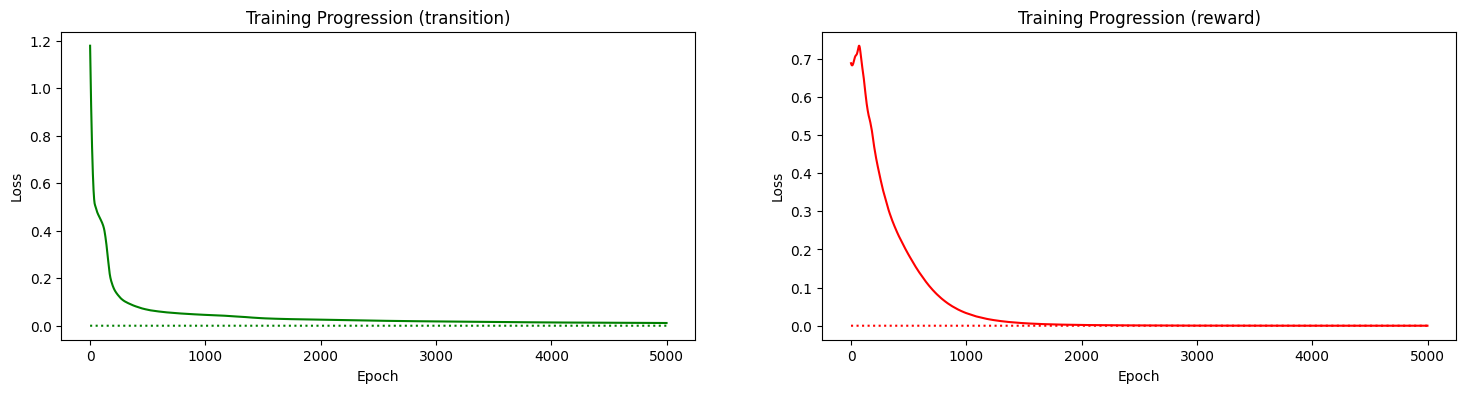

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(18, 4))

data.plot_training_loss(axs[0])
data.plot_training_loss(axs[1], train_data.reward, 'r')

plt.show()

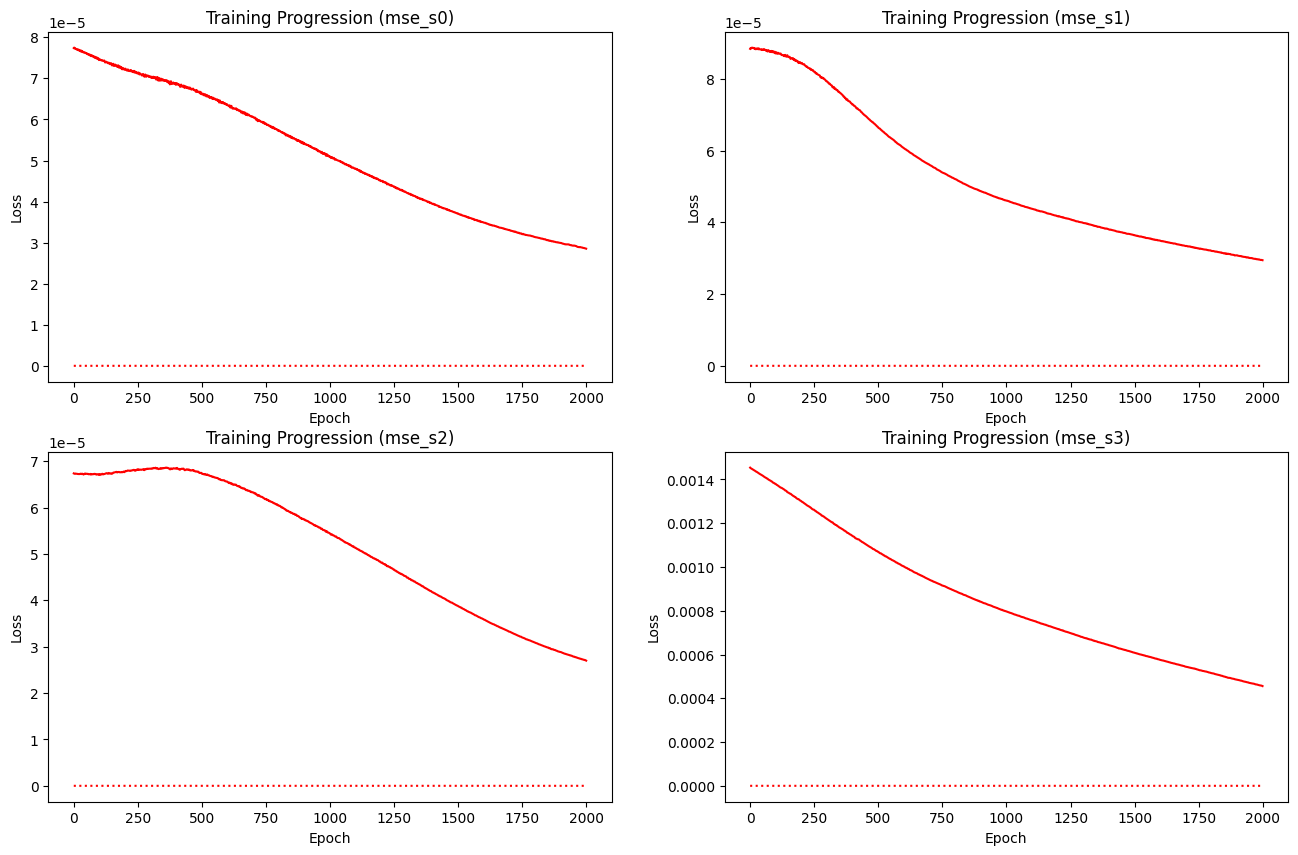

In [5]:
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
    # 'mse_negative': ['mse_negative_p0', 'mse_negative_p1'],
    # 'mse_positive': ['mse_positive_p0', 'mse_positive_p1'],
}

df = get_data_expanded(train_data, expansions)

for i,col in enumerate(expansions['mse_s']):
    # data.plot_training_loss(axs[i//2][i%2], df[col], 'r')
    data.plot_training_loss(axs[i//2][i%2], df[col].tail(2000).reset_index(drop=True), 'r')

plt.show()

## Params

In [8]:
import pandas as pd

training_params = pd.DataFrame(y.numpy(), columns=model.targets_lables)

expansions = {
    'p': ['p0', 'p1']
}
df_trainning = get_data_expanded(data.training_data.loc[(data.training_data.epoch==499)], expansions)

df_trainning_p = pd.DataFrame([], columns=['epoch', 'positive_p0', 'positive_p1', 'negative_p0', 'negative_p1', 'p0', 'p1'])
for epoch in df_trainning.epoch.unique():
    copy = df_trainning[df_trainning.epoch == epoch].copy()[['epoch', 'p0', 'p1']].reset_index(drop=True)
    copy[['sample', 'positive_p0', 'positive_p1', 'negative_p0', 'negative_p1']] = training_params.copy()[['positive_p0', 'positive_p1', 'negative_p0', 'negative_p1']].reset_index()
    df_trainning_p = pd.concat([df_trainning_p, copy])

df_trainning_p.head()

/tmp/ipykernel_9807/580248604.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_trainning_p = pd.concat([df_trainning_p, copy])


,epoch,positive_p0,positive_p1,negative_p0,negative_p1,p0,p1,sample
0,499,0.055887,1.027725,0.341410,0.515999,0.110185,1.060298,0.0
1,499,0.244447,0.484683,0.437765,0.972957,0.235503,0.439447,1.0
2,499,0.228648,0.857469,0.281366,1.119156,0.292331,1.016930,2.0
3,499,0.318369,0.945263,0.143303,1.807597,0.222463,0.404448,3.0
4,499,0.124666,0.250438,0.182529,0.917305,0.236689,0.348621,4.0


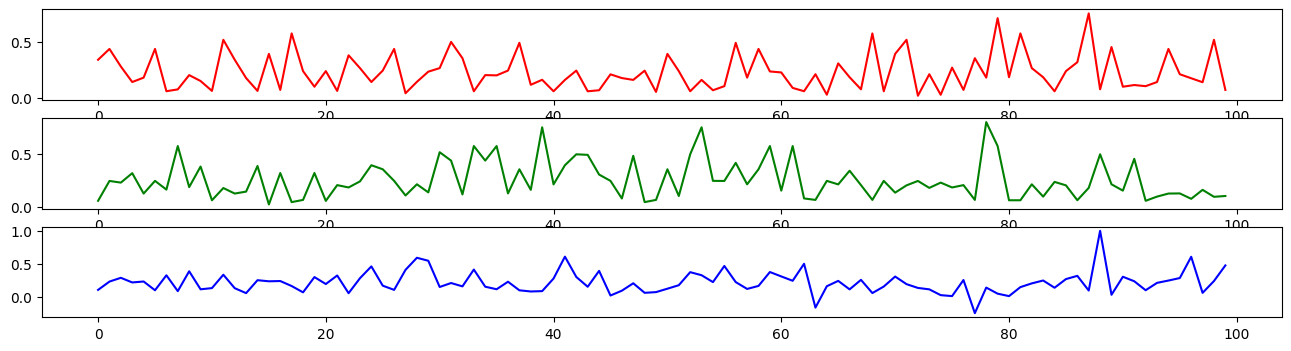

In [9]:
fig, axs = plt.subplots(3, 1, figsize=(16, 4))

axs[0].plot(df_trainning_p.loc[(df_trainning_p.epoch==499) & (df_trainning_p['sample']<100)]['negative_p0'], color='r', label='negative')
axs[1].plot(df_trainning_p.loc[(df_trainning_p.epoch==499) & (df_trainning_p['sample']<100)]['positive_p0'], color='g', label='positve')
axs[2].plot(df_trainning_p.loc[(df_trainning_p.epoch==499) & (df_trainning_p['sample']<100)]['p0'], color='b', label='estimative')

plt.show()

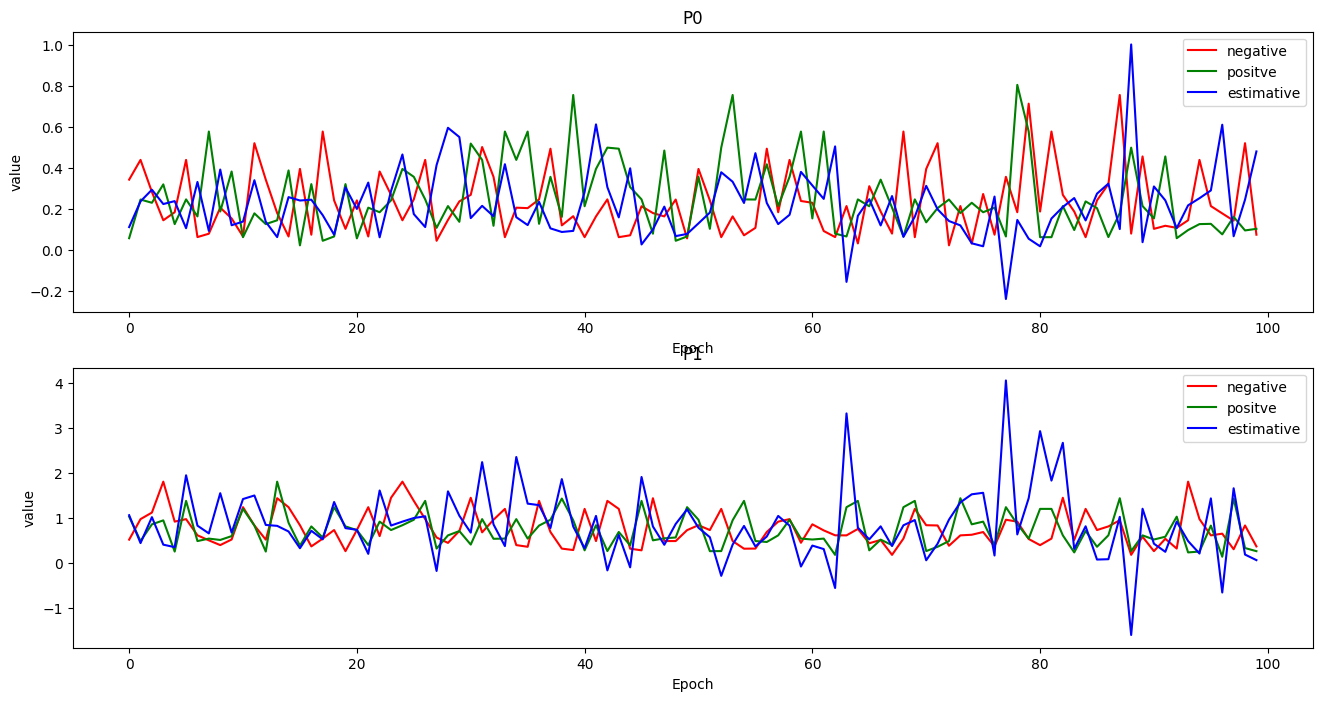

In [10]:
fig, axs = plt.subplots(2,1, figsize=(16, 8))

# df = df_trainning_p.groupby('epoch').mean()
# df = df_trainning_p.groupby('sample').mean()
df = df_trainning_p.loc[(df_trainning_p.epoch==499) & (df_trainning_p['sample']<100)]

axs[0].plot(df['negative_p0'], color='r', label='negative')
axs[0].plot(df['positive_p0'], color='g', label='positve')
axs[0].plot(df['p0'], color='b', label='estimative')

axs[0].set_ylabel('value')
axs[0].set_xlabel('Epoch')
axs[0].set_title(f'P0')
axs[0].legend()

axs[1].plot(df['negative_p1'], color='r', label='negative')
axs[1].plot(df['positive_p1'], color='g', label='positve')
axs[1].plot(df['p1'], color='b', label='estimative')

axs[1].set_ylabel('value')
axs[1].set_xlabel('Epoch')
axs[1].set_title(f'P1')
axs[1].legend()

plt.show()

## Best and worst episodes

In [11]:
data.evaluate_model(model, path='../training_data.csv')
results = data.get_evaluation_metrics()
results.head()

,step,episode,p,s,a,r,s_,a_,r_,s__,...,rse_s0,rse_s1,rse_s2,rse_s3,rse_r,rse_s0_normalized,rse_s1_normalized,rse_s2_normalized,rse_s3_normalized,rse
0,0,0,"(0.0730412080386606, 0.3656961190344961)","(0.011, 0.034, 0.014, 0.009)",0,1.0,"(0.012, -0.165, 0.014, 0.407)",0.0,1.0,"(0.009, -0.365, 0.023, 0.806)",...,0.002,0.004,0.000,0.104,0.0,0.404246,0.419760,0.498801,0.579601,0.110
1,1,0,"(0.0730412080386606, 0.3656961190344961)","(0.012, -0.165, 0.014, 0.407)",0,1.0,"(0.009, -0.365, 0.023, 0.806)",0.0,1.0,"(0.001, -0.565, 0.039, 1.207)",...,0.001,0.008,0.001,0.060,0.0,0.403830,0.420457,0.501199,0.576960,0.070
2,2,0,"(0.0730412080386606, 0.3656961190344961)","(0.009, -0.365, 0.023, 0.806)",0,1.0,"(0.001, -0.565, 0.039, 1.207)",0.0,1.0,"(-0.01, -0.766, 0.063, 1.616)",...,0.003,0.009,0.001,0.025,0.0,0.404663,0.420631,0.501199,0.574859,0.038
3,3,0,"(0.0730412080386606, 0.3656961190344961)","(0.001, -0.565, 0.039, 1.207)",0,1.0,"(-0.01, -0.766, 0.063, 1.616)",1.0,1.0,"(-0.025, -0.567, 0.095, 1.25)",...,0.002,0.006,0.001,0.144,0.0,0.404246,0.420108,0.501199,0.582003,0.153
4,4,0,"(0.0730412080386606, 0.3656961190344961)","(-0.01, -0.766, 0.063, 1.616)",1,1.0,"(-0.025, -0.567, 0.095, 1.25)",1.0,1.0,"(-0.036, -0.369, 0.12, 0.9)",...,0.001,0.002,0.001,0.125,0.0,0.403830,0.419411,0.501199,0.580862,0.129


In [12]:
rmse = results[['episode', 'rse_s0', 'rse_s1', 'rse_s2', 'rse_s3']].groupby('episode').mean().reset_index()
rmse['rmse'] = rmse.rse_s0 + rmse.rse_s1 + rmse.rse_s2 + rmse.rse_s3
rmse_sorted = rmse.sort_values(by='rmse')
epis = rmse.shape[0]

best_episodes = rmse_sorted.head(3).episode.values
worst_episodes = rmse_sorted.tail(3).episode.values
print(f'{best_episodes=}', f'{worst_episodes=}')

best_episodes=array([87, 49, 11]) worst_episodes=array([20, 17, 32])


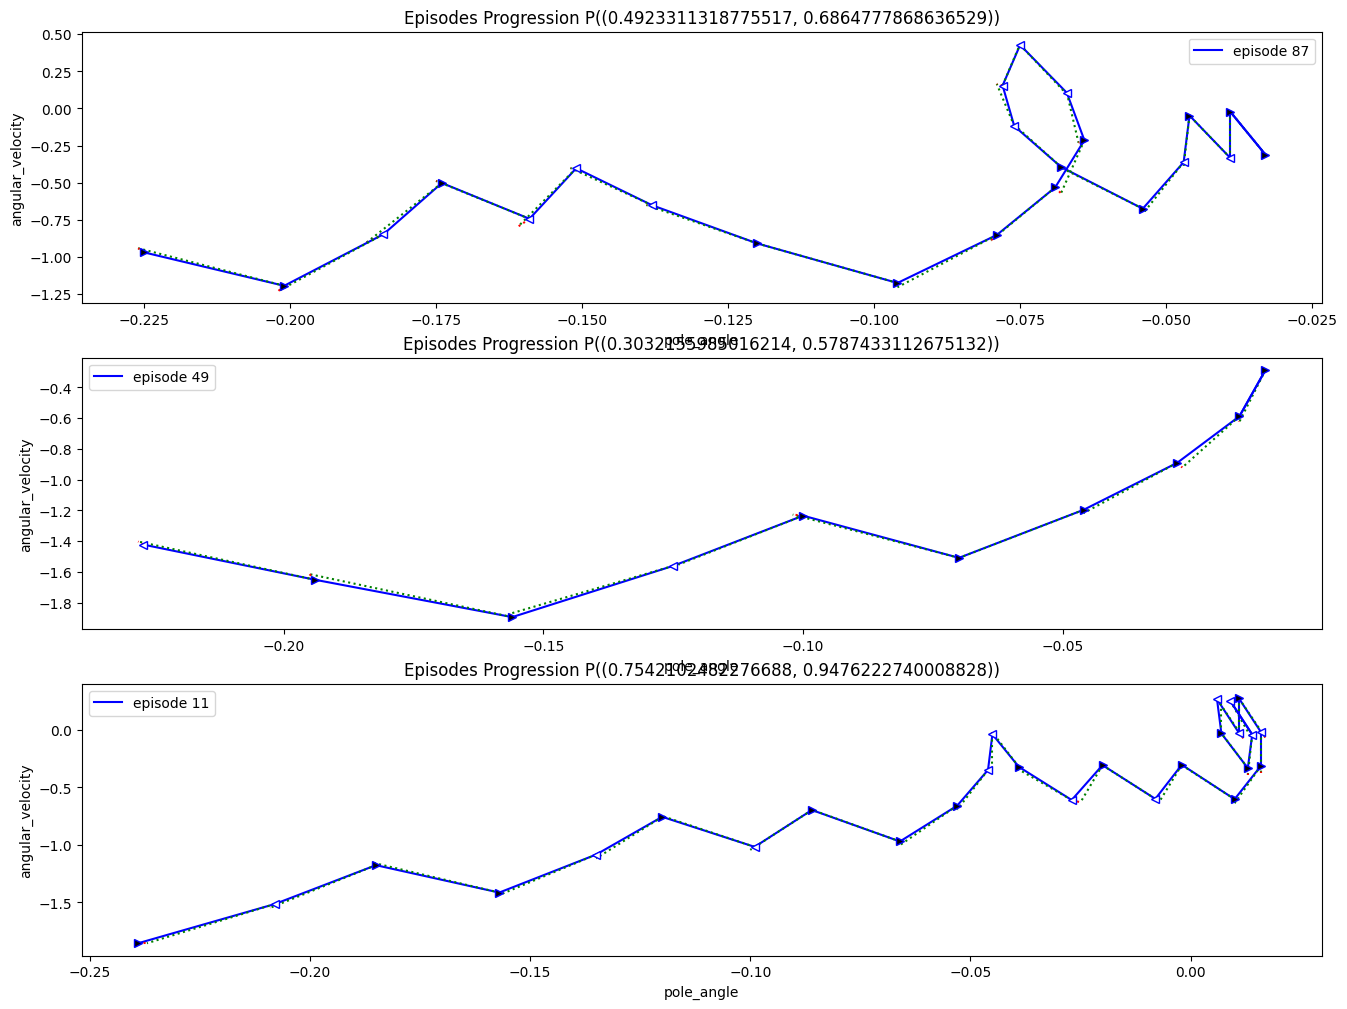

In [13]:
fig, axs = plt.subplots(3, 1, figsize=(16, 12))

for i, epi in enumerate(best_episodes):
    data.plot_episode_progression_with_predictions(axs[i], epi)
plt.show()

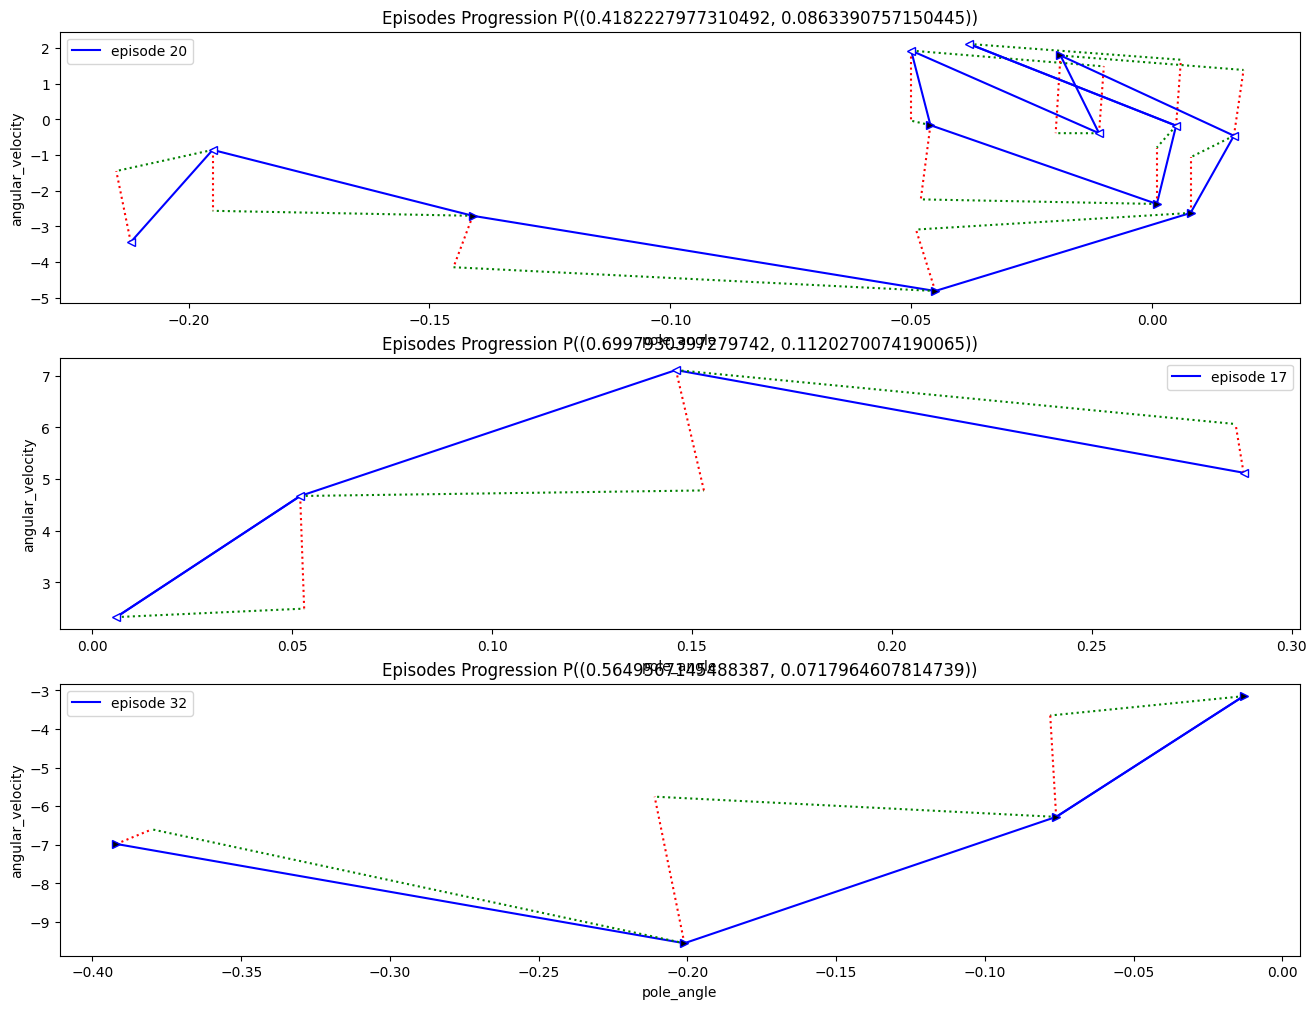

In [14]:
fig, axs = plt.subplots(3, 1, figsize=(16, 12))

for i, epi in enumerate(worst_episodes):
    data.plot_episode_progression_with_predictions(axs[i], epi)
plt.show()

## Kmeans

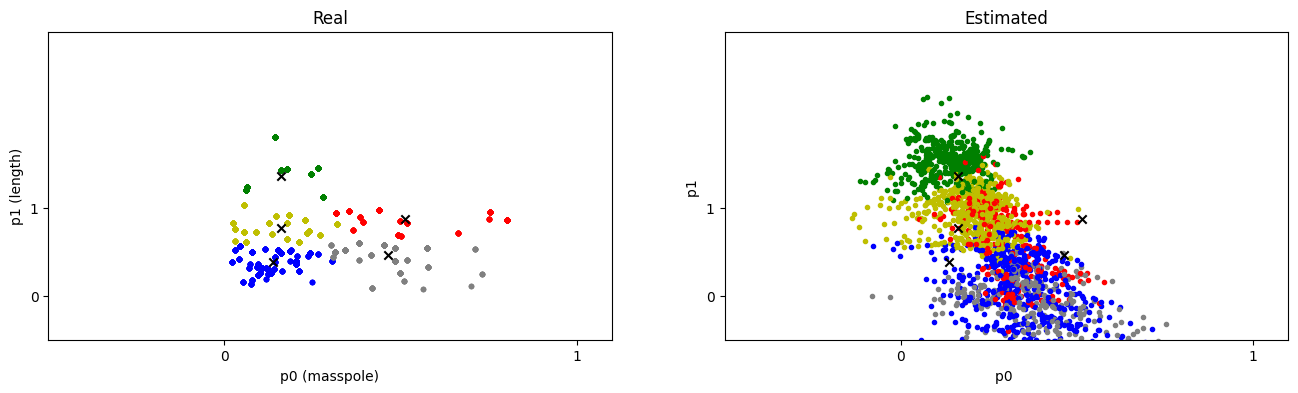

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4))
data.plot_clusters(axs, results)
plt.show()

# Evaluation

In [16]:
data.evaluate_model(model, path='../testing_data.csv')
results = data.get_evaluation_metrics()
results.head()

,step,episode,p,s,a,r,s_,a_,r_,s__,...,rse_s0,rse_s1,rse_s2,rse_s3,rse_r,rse_s0_normalized,rse_s1_normalized,rse_s2_normalized,rse_s3_normalized,rse
0,0,0,"(0.5280280669895349, 0.1691488904272192)","(-0.018, -0.046, 0.013, -0.019)",0,1.0,"(-0.019, -0.285, 0.013, 1.258)",0.0,1.0,"(-0.025, -0.525, 0.038, 2.534)",...,0.003,0.026,0.001,1.012,0.0,0.549102,0.532448,0.503597,0.521263,1.042
1,1,0,"(0.5280280669895349, 0.1691488904272192)","(-0.019, -0.285, 0.013, 1.258)",0,1.0,"(-0.025, -0.525, 0.038, 2.534)",1.0,1.0,"(-0.035, -0.288, 0.088, 1.326)",...,0.004,0.027,0.002,0.940,0.0,0.550158,0.532694,0.505995,0.515102,0.973
2,2,0,"(0.5280280669895349, 0.1691488904272192)","(-0.025, -0.525, 0.038, 2.534)",1,1.0,"(-0.035, -0.288, 0.088, 1.326)",0.0,1.0,"(-0.041, -0.532, 0.115, 2.694)",...,0.001,0.025,0.000,1.076,0.0,0.546990,0.532203,0.501199,0.526739,1.102
3,3,0,"(0.5280280669895349, 0.1691488904272192)","(-0.035, -0.288, 0.088, 1.326)",0,1.0,"(-0.041, -0.532, 0.115, 2.694)",1.0,1.0,"(-0.052, -0.3, 0.169, 1.601)",...,0.005,0.018,0.001,0.851,0.0,0.551214,0.530482,0.503597,0.507487,0.875
4,4,0,"(0.5280280669895349, 0.1691488904272192)","(-0.041, -0.532, 0.115, 2.694)",1,1.0,"(-0.052, -0.3, 0.169, 1.601)",0.0,1.0,"(-0.058, -0.546, 0.201, 3.045)",...,0.007,0.024,0.001,1.123,0.0,0.553326,0.531957,0.503597,0.530761,1.155


In [17]:
results[['rse_s0','rse_s1','rse_s2','rse_s3','rse_r','rse_s0_normalized','rse_s1_normalized','rse_s2_normalized','rse_s3_normalized', 'rse']].describe()

,rse_s0,rse_s1,rse_s2,rse_s3,rse_r,rse_s0_normalized,rse_s1_normalized,rse_s2_normalized,rse_s3_normalized,rse
count,2127.000000,2127.000000,2127.000000,2127.000000,2127.0,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000
mean,0.002900,0.012549,0.001179,0.173354,0.0,0.548997,0.529142,0.504026,0.449504,0.189982
std,0.003104,0.015029,0.001431,0.216211,0.0,0.003278,0.003695,0.003431,0.018500,0.226597
min,0.000000,0.000000,0.000000,0.000000,0.0,0.545935,0.526057,0.501199,0.434671,0.004000
25%,0.001000,0.004000,0.000000,0.062000,0.0,0.546990,0.527040,0.501199,0.439976,0.073000
50%,0.002000,0.009000,0.001000,0.117000,0.0,0.548046,0.528269,0.503597,0.444682,0.131000
75%,0.004000,0.015000,0.001000,0.201000,0.0,0.550158,0.529744,0.503597,0.451870,0.217000
max,0.034000,0.165000,0.015000,2.202000,0.0,0.581837,0.566618,0.537170,0.623085,2.331000


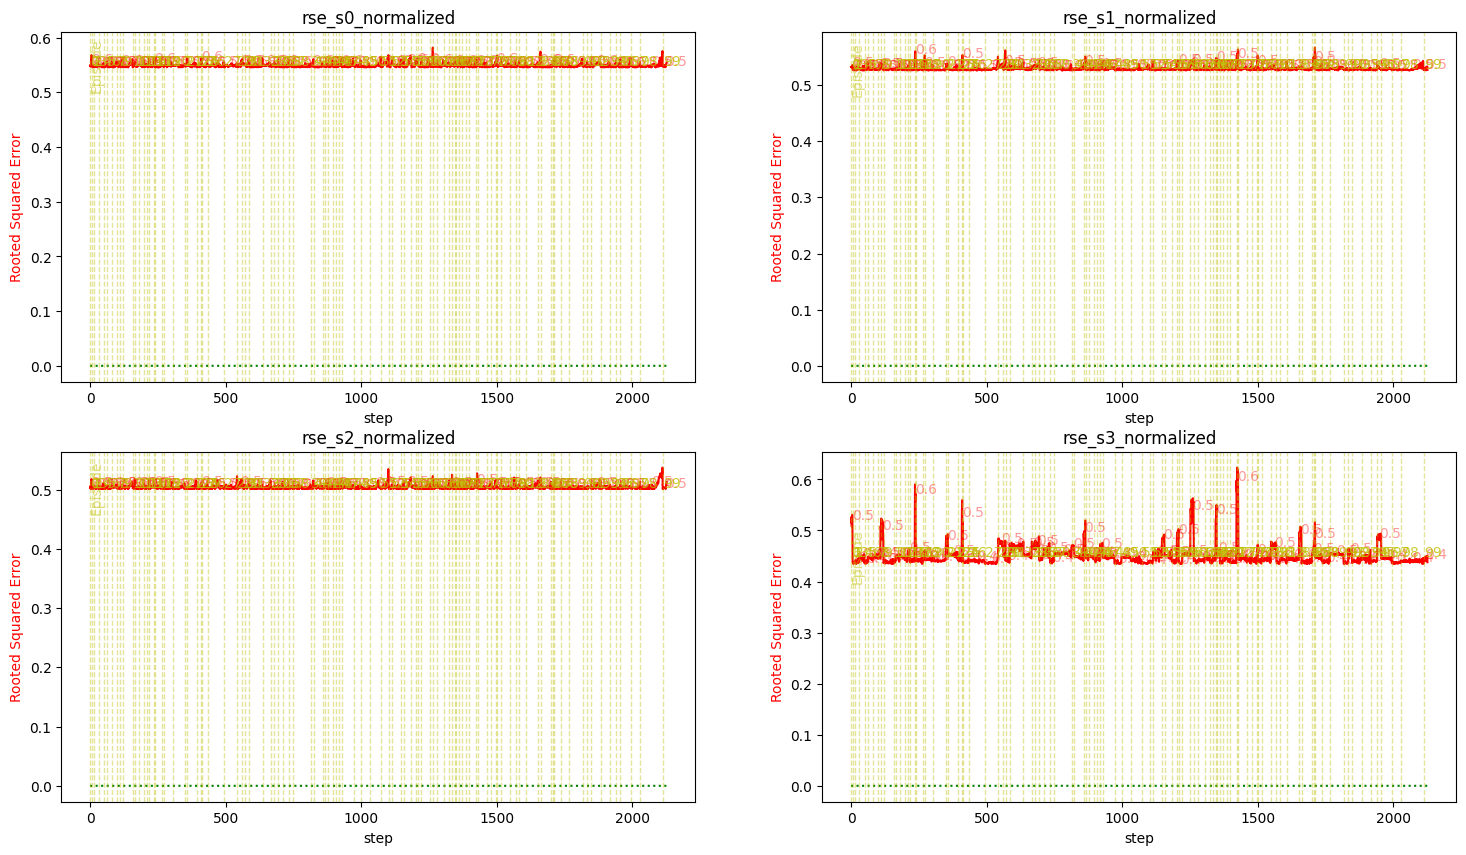

In [18]:
fig, axs = plt.subplots(2, 2, figsize=(18,10))

data.plot_value_through_episodes(axs[0][0], results, 'rse_s0_normalized')
data.plot_value_through_episodes(axs[0][1], results, 'rse_s1_normalized')
data.plot_value_through_episodes(axs[1][0], results, 'rse_s2_normalized')
data.plot_value_through_episodes(axs[1][1], results, 'rse_s3_normalized')

plt.show()

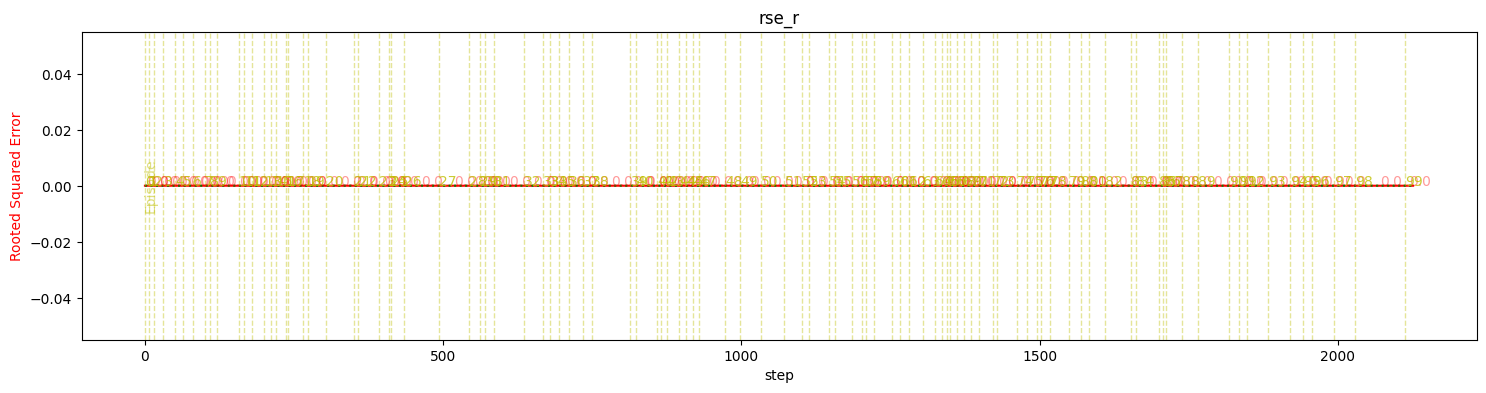

In [19]:
fig, axs = plt.subplots(1, 1, figsize=(18,4))
data.plot_value_through_episodes(axs, results, 'rse_r')
plt.show()

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/gui/Área de Trabalho/rlalgs/.venv/lib/pyt

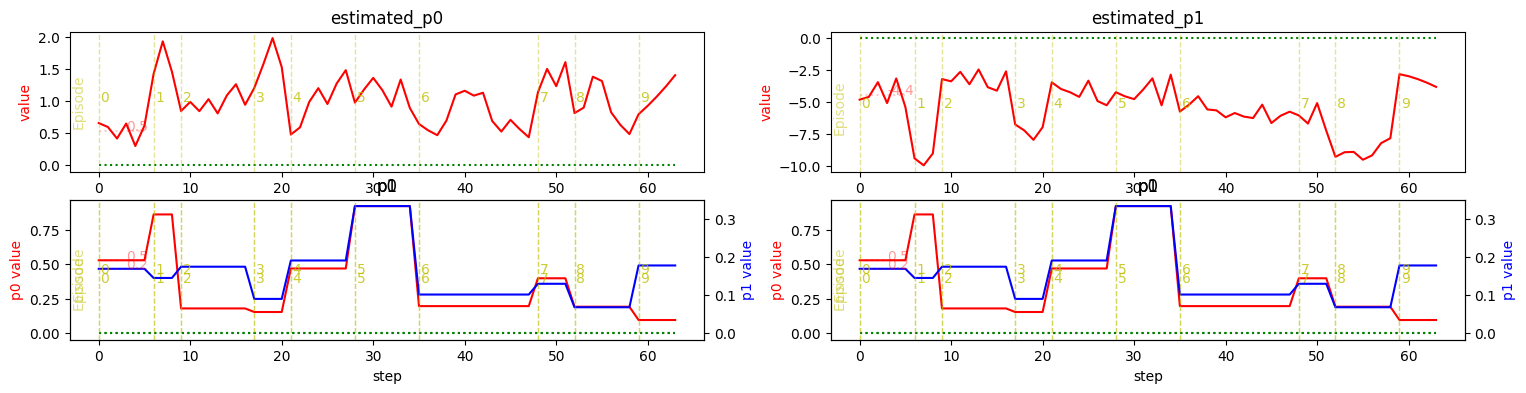

In [20]:
import numpy as np 
n = 10

df = results[['episode', 'estimated_p0', 'estimated_p1', 'p0', 'p1']].groupby("episode").mean().reset_index()
df['dist_p0'] = np.sqrt(np.pow(df['estimated_p0']-df['p0'], 2))
df['dist_p1'] = np.sqrt(np.pow(df['estimated_p1']-df['p1'], 2))
df['dist'] = df['dist_p0'] + df['dist_p1']
worst = df.loc[df.rank(ascending=False)['dist']<=n].episode
df = results[results['episode'].isin(worst)].reset_index(drop=True)

fig, axs = plt.subplots(2, 2, figsize=(18,4))
data.plot_value_through_episodes(axs[0][0], df, 'estimated_p0', y_label='value')
data.plot_value_through_episodes(axs[0][1], df, 'estimated_p1', y_label='value')

data.plot_value_through_episodes(axs[1][0], df, 'p0', y_label='p0 value')
data.plot_value_through_episodes(axs[1][0].twinx(), df, 'p1', y_label='p1 value', color='b')

data.plot_value_through_episodes(axs[1][1], df, 'p0', y_label='p0 value')
data.plot_value_through_episodes(axs[1][1].twinx(), df, 'p1', y_label='p1 value', color='b')

plt.show()

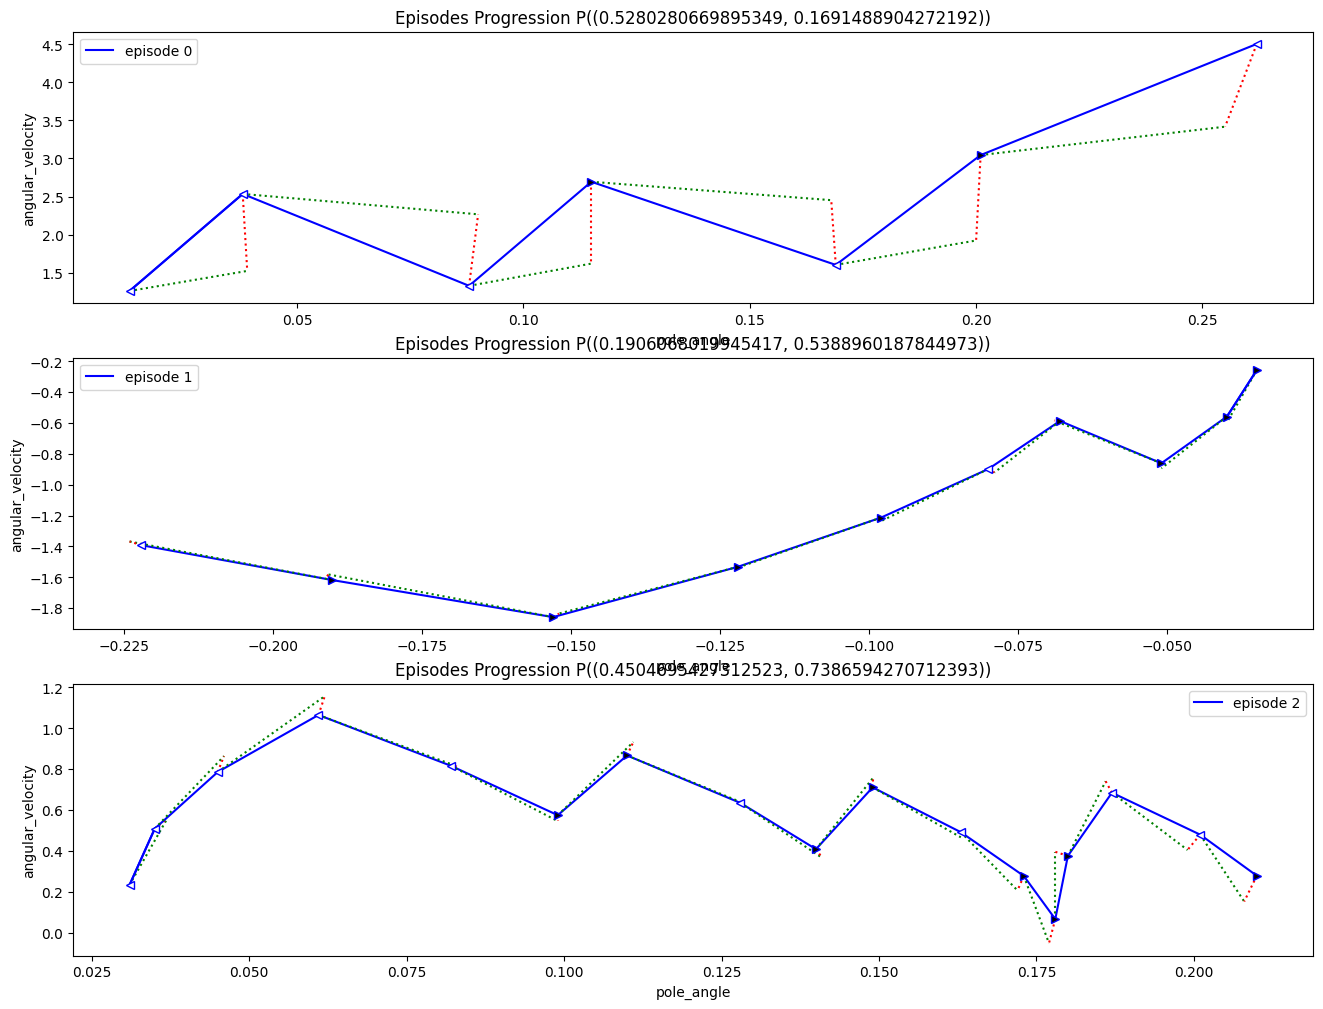

In [21]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(16, 12))
data.plot_episode_progression_with_predictions(axs[0], 0)
data.plot_episode_progression_with_predictions(axs[1], 1)
data.plot_episode_progression_with_predictions(axs[2], 2)
plt.show()

## Cluster

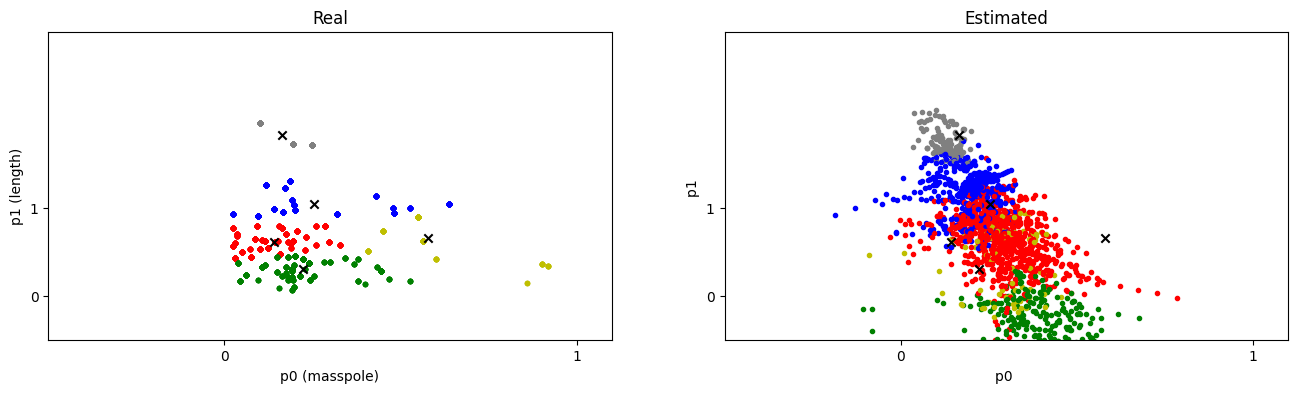

In [22]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4))
data.plot_clusters(axs, results)
plt.show()

In [ ]:
# import pickle

# exp = {
#     "data": data,
#     "model": model 
# }

# nome_do_arquivo = 'triplet.pkl'
# with open(nome_do_arquivo, 'wb') as arquivo:
#     pickle.dump(exp, arquivo)